In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0


Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0

--- DataFrame Head ---
   study_hours  attendance  assignments result
0            5          80            8   Pass
1            2          60            5   Fail
2            7          90            9   Pass
3            1          50            4   Fail
4            8          95           10   Pass

--- Groupby Mean ---
        study_hours  attendance  assignments
result                                      
Fail            2.5        60.4          4.8
Pass            7.0        88.3          8.8


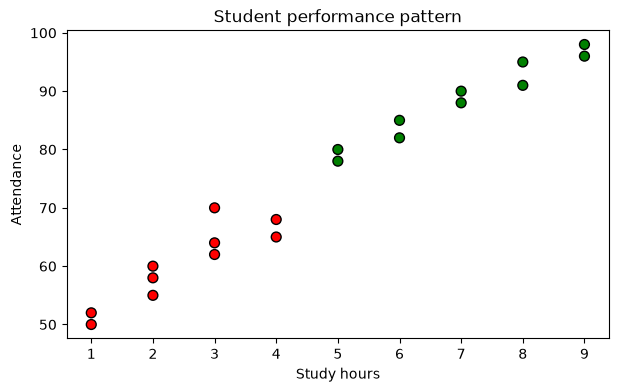


X shape: (20, 3)
y shape: (20,)
Training rows: 16
Testing rows : 4

Model trained!


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

# 1. Creating a Dataset to save a CSV file.
data = {
    'study_hours': [5, 2, 7, 1, 8, 3, 6, 4, 9, 2, 6, 3, 8, 1, 7, 4, 9, 2, 5, 3],
    'attendance': [80, 60, 90, 50, 95, 70, 85, 65, 98, 55, 82, 62, 91, 52, 88, 68, 96, 58, 78, 64],
    'assignments': [8, 5, 9, 4, 10, 6, 8, 6, 10, 3, 8, 5, 9, 4, 9, 6, 10, 4, 7, 5],
    'result': ['Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail',
               'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail']
}
pd.DataFrame(data).to_csv("student_performance.csv", index=False)

# 2. File optimization
df = pd.read_csv("student_performance.csv")
df.columns = df.columns.str.strip()

print("\n--- DataFrame Head ---")
print(df.head())

print("\n--- Groupby Mean ---")
print(df.groupby("result")[["study_hours", "attendance", "assignments"]].mean())

# 3. Visualization
plt.figure(figsize=(7, 4))
#Matplotlib indicates 'Pass'/'Fail' in colors
colors = df["result"].map({'Pass': 'green', 'Fail': 'red'})
plt.scatter(df["study_hours"], df["attendance"], c=colors, edgecolors="k", s=50)
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()

# 4. Machine Learning Data Setup
X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

# 5. Model Training
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained!")

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy: .2%}")

Test accuracy:  100.00%


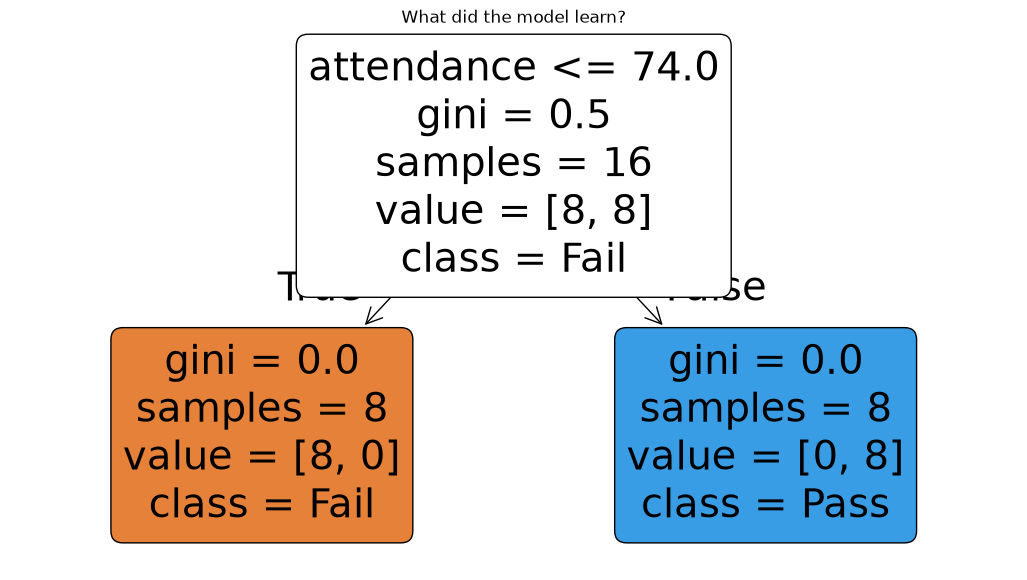

In [25]:
plt.figure(figsize=(13, 7))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True, 
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

--- Learned Q-Table Data (Sample States) ---
         Up  Down  Left  Right
State                         
0      0.51 -0.10  0.40   1.81
1      1.62 -6.08  0.29   3.12
2      2.64  4.58  1.45   3.70
3      0.36  6.15  0.14   1.08
4     -1.62  1.83 -1.24  -5.17
5      0.07  0.30 -0.58   4.55
6      2.72  5.10 -5.84   6.20
7      3.60  8.00  4.20   5.49
8     -1.20 -0.90 -0.53   3.96
9     -4.05 -0.21 -0.47   6.05


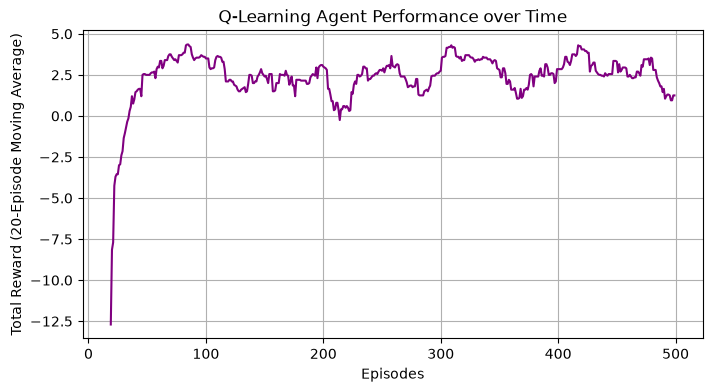


Optimal Path Learned by Agent from Start (0) to Goal (15):
0 -> 1 -> 2 -> 6 -> 7 -> 11 -> 15


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Environment Parameters Setup
num_states = 16  # 4x4 Grid
num_actions = 4  # 0: Up, 1: Down, 2: Left, 3: Right
action_names = ['Up', 'Down', 'Left', 'Right']

# Helper function: To calculate next state and reward
def step(state, action):
    row, col = divmod(state, 4)
    
    if action == 0:    # Up
        row = max(0, row - 1)
    elif action == 1:  # Down
        row = min(3, row + 1)
    elif action == 2:  # Left
        col = max(0, col - 1)
    elif action == 3:  # Right
        col = min(3, col + 1)
    
    next_state = row * 4 + col
    
    # Reward Logic
    if next_state == 15:    # Goal
        reward = 10
    elif next_state == 5:   # Trap
        reward = -10
    else:                   # Step Penalty
        reward = -1
        
    return next_state, reward

# 2. Q-Learning Hyperparameters
alpha = 0.1     # Learning Rate
gamma = 0.9     # Discount Factor
epsilon = 0.2   # Exploration Rate (Trial & Error probability)
episodes = 500

# Q-Table Initialization (Data matrix: 16 States x 4 Actions)
Q_table = np.zeros((num_states, num_actions))

# 3. Training Loop (Agent learns through experience)
rewards_history = []

for episode in range(episodes):
    state = 0  # Start state
    total_reward = 0
    done = False
    steps = 0
    
    while not done and steps < 50:
        steps += 1
        
        # Epsilon-Greedy Action Selection
        if np.random.rand() < epsilon:
            action = np.random.choice(num_actions) # Explore (Random Action)
        else:
            action = np.argmax(Q_table[state])     # Exploit (Best Action so far)
            
        next_state, reward = step(state, action)
        
        # Q-Learning Formula Update:
        # Q(s,a) = Q(s,a) + alpha * [Reward + gamma * max(Q(s',a')) - Q(s,a)]
        best_next_action = np.argmax(Q_table[next_state])
        td_target = reward + gamma * Q_table[next_state, best_next_action]
        Q_table[state, action] += alpha * (td_target - Q_table[state, action])
        
        state = next_state
        total_reward += reward
        
        if state == 15: # Reached Goal
            done = True
            
    rewards_history.append(total_reward)

# 4. Display Learned Q-Table (Data Output)
df_q_table = pd.DataFrame(Q_table, columns=action_names)
df_q_table.index.name = "State"

print("--- Learned Q-Table Data (Sample States) ---")
print(df_q_table.round(2).head(10))

# 5. Training Progress Visualization
plt.figure(figsize=(8, 4))
plt.plot(pd.Series(rewards_history).rolling(window=20).mean(), color='purple')
plt.xlabel("Episodes")
plt.ylabel("Total Reward (20-Episode Moving Average)")
plt.title("Q-Learning Agent Performance over Time")
plt.grid(True)
plt.show()

# 6. Testing the Optimal Learned Path
state = 0
path = [state]
while state != 15:
    action = np.argmax(Q_table[state])
    state, _ = step(state, action)
    path.append(state)

print("\nOptimal Path Learned by Agent from Start (0) to Goal (15):")
print(" -> ".join(map(str, path)))

Starting Reinforcement Learning (Contextual Bandit) on Student Data...


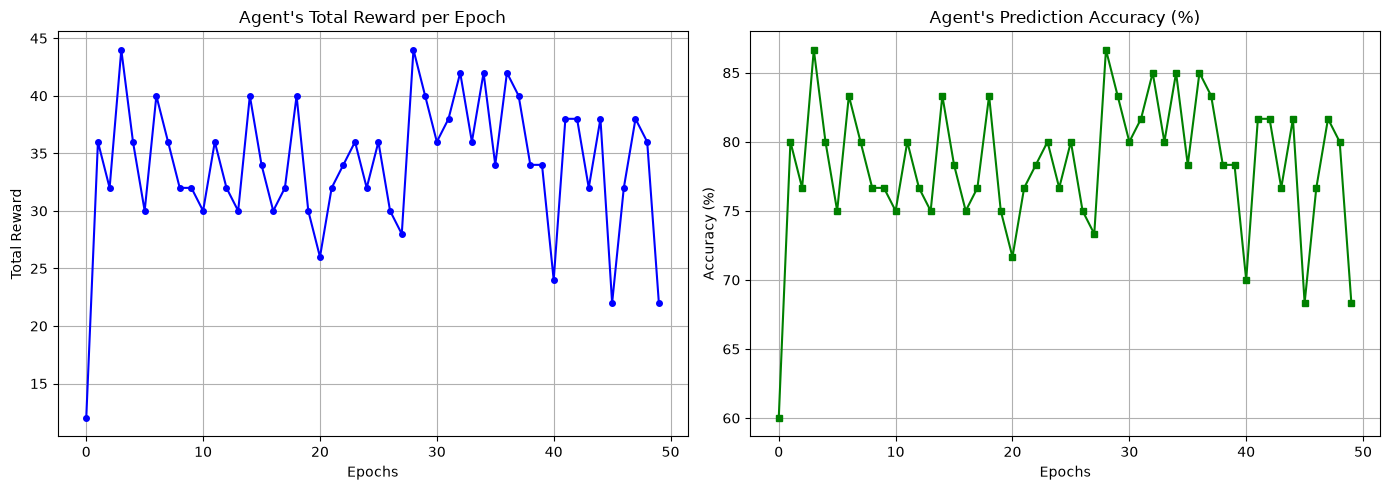


--- Model Evaluation ---
Final Epoch Accuracy: 68.33%
Total Unique States Discovered: 13

--- Learned Q-Table Data (Sample 10 rows) ---
 Action 0 (Fail)  Action 1 (Pass) State Config (Study_Att_Asg)
            1.00            -0.88                        0_0_0
            1.00            -0.88                        0_0_1
           -0.33             0.17                        1_1_1
           -1.00             1.00                        1_1_2
           -1.00             1.00                        2_2_2
            0.17            -0.55                        1_0_2
            1.00            -0.52                        0_1_0
           -0.99             1.00                        2_1_2
            1.00            -0.99                        0_1_1
            1.00            -0.88                        1_0_1


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Starting Reinforcement Learning (Contextual Bandit) on Student Data...")

# 1. 60 Rows Exact Data Embed (No CSV required)
data = {
    'student_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60],
    'study_hours': [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 0.5, 1.2, 2.2, 2.8, 3.2, 0.8, 4.2, 5.5, 1.8, 3.8, 2.0, 4.8, 1.0, 2.6, 3.0, 0.7, 5.0, 1.7, 3.6, 2.4, 4.4, 1.3, 3.1, 2.1, 4.0, 0.9, 3.7, 2.9, 1.4, 4.6, 2.7, 3.4, 1.1, 4.9, 2.3, 3.9, 1.6, 4.1, 2.5, 3.3, 0.6, 4.7, 2.2, 3.5, 1.9, 5.2, 2.8, 3.0, 1.5, 4.3, 2.6],
    'attendance': [58, 62, 65, 68, 72, 75, 78, 82, 85, 45, 55, 70, 66, 60, 72, 74, 88, 80, 69, 50, 77, 90, 73, 64, 61, 70, 67, 83, 76, 79, 69, 81, 58, 86, 52, 74, 71, 78, 84, 63, 73, 65, 80, 69, 76, 82, 68, 57, 75, 48, 88, 62, 79, 71, 83, 59, 77, 74, 82, 68],
    'assignments': [3, 5, 6, 7, 7, 8, 9, 9, 10, 2, 4, 6, 8, 9, 3, 8, 10, 5, 9, 7, 8, 4, 7, 8, 5, 9, 6, 8, 5, 10, 5, 7, 8, 8, 6, 7, 8, 4, 9, 7, 8, 5, 10, 6, 9, 4, 9, 8, 7, 3, 9, 8, 8, 6, 10, 7, 9, 5, 9, 6],
    'result': [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# 2. RL Environment Setup
def get_state(row):
    # 0 = Low, 1 = Medium, 2 = High
    s = 0 if row['study_hours'] < 2.0 else (1 if row['study_hours'] <= 4.0 else 2)
    a = 0 if row['attendance'] < 65 else (1 if row['attendance'] <= 80 else 2)
    asg = 0 if row['assignments'] < 5 else (1 if row['assignments'] <= 7 else 2)
    return f"{s}_{a}_{asg}" # Jaise "1_2_1" (Medium Study, High Attendance, Medium Assignments)

df['State'] = df.apply(get_state, axis=1)

# Har unique halat ko ek number de rahe hain taaki matrix mein rakh sakein
unique_states = df['State'].unique()
state_to_idx = {state: idx for idx, state in enumerate(unique_states)}

# 3. RL Agent Parameters (Q-Table)
num_states = len(unique_states)
num_actions = 2  # Action 0 (Predict Fail), Action 1 (Predict Pass)
Q_table = np.zeros((num_states, num_actions))

alpha = 0.1     # Learning rate Priority for new knowlegde)
epsilon = 0.3   # Exploration rate (attempts to learn the new data)
epochs = 50     # The agent will revise the data 50 times to learn

accuracy_history = []
rewards_history = []

# 4. Training Loop 
for epoch in range(epochs):
    shuffled_df = df.sample(frac=1, random_state=epoch).reset_index(drop=True)
    
    total_reward = 0
    correct_preds = 0
    
    for _, row in shuffled_df.iterrows():
        state_idx = state_to_idx[row['State']]
        true_result = row['result']
        
        # Action Selection (Epsilon-Greedy Strategy)
        if np.random.rand() < epsilon:
            action = np.random.choice([0, 1])  # Explore (random guessing)
        else:
            action = np.argmax(Q_table[state_idx])  # Exploit (Taking the best action based on the knowlegde)
            
        # Taking reward/Penalty 
        if action == true_result:
            reward = 1
            correct_preds += 1
        else:
            reward = -1
            
        # Q-Table Update Rule (Q(s, a) Update)
        Q_table[state_idx, action] += alpha * (reward - Q_table[state_idx, action])
        total_reward += reward
        
    accuracy_history.append((correct_preds / len(df)) * 100)
    rewards_history.append(total_reward)

# 5. Visualization & Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Total Rewards 
ax1.plot(rewards_history, color='blue', marker='o', markersize=4)
ax1.set_title("Agent's Total Reward per Epoch")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Total Reward")
ax1.grid(True)

# Graph 2: Accuracy
ax2.plot(accuracy_history, color='green', marker='s', markersize=4)
ax2.set_title("Agent's Prediction Accuracy (%)")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Final Q-Table (Data Output)
print("\n--- Model Evaluation ---")
print(f"Final Epoch Accuracy: {accuracy_history[-1]:.2f}%")
print(f"Total Unique States Discovered: {num_states}")

q_df = pd.DataFrame(Q_table, columns=['Action 0 (Fail)', 'Action 1 (Pass)'])
q_df['State Config (Study_Att_Asg)'] = unique_states
print("\n--- Learned Q-Table Data (Sample 10 rows) ---")
print(q_df.head(10).round(2).to_string(index=False))